# Fundamentals of Agentic AI

This workshop provides an introduction to the fundamental concepts that build a smart agent. Starting from understanding what an agent is and how it interacts with its environment, we will deconstruct an agent to understand its individual components - Prompts, Tools, Agent State, StateGraph and then cover a few advanced concepts such as Reasoning and Action (ReAct) agents and Human-In-The-Loop. As we dive into advanced topics, we will build agents using all the components learnt in this workshop and apply them to industry problems.


### **Introduction**

An **agent** is an entity that can **act** autonomously in an **environment**.

To act, **agent** needs to perceive its **environment** through **sensors** and take actions within that environment using **actuators**, as illustrated in the following image:

[![fig1.png](https://i.postimg.cc/QC8YxZTx/fig1.png)](https://postimg.cc/8JYmt34q)

A **rational agent** is one that chooses actions that lead to the **best possible outcome** it can, based on its perception and decision-making capabilities.

While rational agents have been a concept in computer science for decades, a persistent challenge has been how to make them truly **rational** in complex, dynamic environments. This is where **large language models (LLMs)** have become a transformative solution, providing the reasoning and decision-making abilities previously out of reach.




### **Task Environment**:


Task environments are essentially the “problems” to which rational agents are the “solutions". Defining properly the **problem** and the **context** in which agents act is key, at it's best, agents will fin a solution, but if the problem is ill-defined, the solution is useless.

Stuart Russel and Peter Norving in AI: A Modern Approach, describe a task environment using the **PEAS** acronym. (**P**erformance, **E**nvironment, **A**ctuators, **S**ensors)

</br>

**Performance**:

This is the problem we are trying to solve, whether it's extracting useful information from a set of documents, arriving safely to destination or writing an essay.
    
</br>

**Environment:**
    
It describes the setting where the agent has to work. This is the most important part to decide if we even need a smart agent:

* In a **deterministic**, **fully observable**, and **known** environment, using an AI agent is usually unnecessary. A simple, well-defined function is often sufficient. </br>
  - *Example: Imagine a factory assembly line. Everything is perfectly organized, and every step is the same every time. You don't need a creative, problem-solving AI here. A simple robot arm that does the same motion over and over is enough.*

* In contrast, in a **stochastic**, **partially observable**, and **unknown** environment, an AI agent is more suitable. Such environments require the agent to handle uncertainty, make informed decisions, and adapt to incomplete information—core strengths of AI systems.
  - *Example: Now imagine a busy downtown Toronto intersection during rush hour. The situation is constantly changing with cars, cyclists, and pedestrians. This is a chaotic environment full of surprises. This is where you need a smart AI (like in a self-driving car) that can handle uncertainty and adapt instantly.*

</br>

**Actuators:**

Actuators are the tools that an agent uses to act upon its environment. In the context of AI agents, these can include components such as a **search engine**, an **API**, a **retrieval-augmented generation (RAG) system**, or any other system the agent can leverage to perform actions and generate outcomes.

</br>

**Sensors:**

The way an agent percieves its environment is through its sensors. A self-driving car that cannot see the road has no useful sensors. In the case of a chatbot, it's sensor might be the input message from the human.





### Types of Agents

* **Goal-Based Agent**:
  This type of agent is designed to solve a specific problem. It selects actions based on whether they will lead to the achievement of a predefined goal. The outcome is typically **binary**—either the goal has been achieved, or it hasn’t.

* **Utility-Based Agent**:
  A step more advanced than goal-based agents, utility-based agents evaluate multiple possible actions by assigning a **utility value** (a measure of desirability or effectiveness) to each outcome. This allows the agent to make better decisions in environments with **greater uncertainty** or **multiple competing outcomes**.

* **Model-Based Agent**:
  These agents build and maintain an **internal model** of the environment to predict the outcomes of actions and make decisions accordingly. While this approach enables more sophisticated reasoning and planning, current models are still limited in their ability to effectively support such agents at scale.


Let's get coding by first installing and importing all relevant Python libraries

In [ ]:
!pip install langgraph==0.6.4
!pip install langchain_openai==0.3.30
!pip install langchain_community==0.3.27
!apt install libgraphviz-dev=2.42.2-6ubuntu0.1
!pip install pygraphviz==1.14
!pip install tavily-python==0.7.10
!pip install langmem==0.0.29
!pip install langgraph-checkpoint-sqlite==2.0.11

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.0/55.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 li

In [ ]:
## Importing all the relevant libraries
import openai
import re
import httpx
import os
from openai import OpenAI
from google.colab import userdata
import pprint
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langmem import create_manage_memory_tool, create_search_memory_tool
import asyncio
from langchain_core.tools import tool
from langgraph.store.memory import InMemoryStore
from langgraph.prebuilt import ToolNode
from typing import Optional

In [ ]:
from langchain_core.runnables import RunnableLambda
from langgraph.graph import StateGraph, END
from typing import Annotated
from langchain_core.messages import AnyMessage
import operator

# Step 1: Define the state
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

# Step 2: Create the graph

graph = StateGraph(AgentState)


# Step 3: Add nodes (like tools or steps)
graph.add_node("echo", RunnableLambda(lambda state: {"messages": state["messages"]}))

# Step 4: Add edges (how nodes connect)
graph.set_entry_point("echo")
graph.set_finish_point("echo")

# Step 5: Compile into a runnable
app = graph.compile()

# Step 6: Run it
result = app.invoke({"messages": [HumanMessage(content="Hello")]})
print(result)


{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}), HumanMessage(content='Hello', additional_kwargs={}, response_metadata={})]}


In [ ]:
client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))
TAVILY_API_KEY=userdata.get('TAVILY_API_KEY')


## **Components of an Agent**

### **Prompts**

Modern AI agents rely on two types of prompts: *system prompts* and *human messages*.

1) The **system prompt** defines the task the agent must perform and sets the rules or context for how it should operate. It guides the language model (LLM) in determining how to respond and whether the task has been successfully completed. In this way, the system prompt serves as the "Performance measure" — the **P** in the PEAS (Performance, Environment, Actuators, Sensors) framework.

2) **Human messages**, on the other hand, are how the agent receives input from its environment. They act as the *sensory input* (**S**) through which the agent perceives what the human wants. In this context, the human and their request represent the agent’s (**E**) environment.







In [ ]:
#Example of a system prompt
prompt = """
You run in a loop of Thought, Action, PAUSE, Observation.
At the end of the loop you output an Answer
Use Thought to describe your thoughts about the question you have been asked.
Use Action to run one of the actions available to you - then return PAUSE.
Observation will be the result of running those actions.

Your available actions are:

calculate:
e.g. calculate: 4 * 7 / 3
Runs a calculation and returns the number - uses Python so be sure to use floating point syntax if necessary

average_dog_weight:
e.g. average_dog_weight: Collie
returns average weight of a dog when given the breed

Example session:

Question: How much does a Bulldog weigh?
Thought: I should look the dogs weight using average_dog_weight
Action: average_dog_weight: Bulldog
PAUSE

You will be called again with this:

Observation: A Bulldog weights 51 lbs

You then output:

Answer: A bulldog weights 51 lbs
""".strip()



### **Tools**

In modern AI agents, *tools* are external functions or systems that the agent can call upon to extend its capabilities beyond pure language understanding and generation. Tools allow the agent to interact with the world in ways that are otherwise outside the LLM's native capabilities — such as searching the web, performing calculations, retrieving documents, or taking actions in a software environment.

In the PEAS framework, tools often correspond to the **Actuators** — they are how the agent *acts* on the environment.

For example:

* A **calculator tool** allows the agent to perform accurate numerical computations.
* A **web search tool** lets the agent gather real-time information from the internet.
* A **code execution tool** enables the agent to write and run programs to solve complex tasks.
* A **database query tool** helps the agent retrieve structured information from internal systems.

Tools are not “understood” by the model in the same way as natural language; rather, the agent must decide *when* and *how* to use each tool appropriately, often guided by system prompts and contextual cues. Once a tool is invoked, the response it returns becomes part of the agent’s new observation — just like a new human message — and the agent uses this feedback to continue reasoning or respond.

In short, tools are how an agent *does things*, bridging the gap between language reasoning and real-world action.

In [ ]:
#Tools as usually functions or API calls.
def calculate(what):
    return eval(what)

def average_dog_weight(name):
    if name in "Scottish Terrier":
        return("Scottish Terriers average 20 lbs")
    elif name in "Border Collie":
        return("a Border Collies average weight is 37 lbs")
    elif name in "Toy Poodle":
        return("a toy poodles average weight is 7 lbs")
    else:
        return("An average dog weights 50 lbs")

known_actions = {
    "calculate": calculate,
    "average_dog_weight": average_dog_weight
}


### **Agent State**

The *agent state* is the internal memory the agent maintains across steps. It allows the agent to reason coherently, track progress, and respond based on prior context.

In LLM-based agents, this state may include:

* **Conversation history** – all prior prompts and responses.
* **Scratchpads** – temporary notes or reasoning steps.
* **Persistent memory** – long-term storage of facts or user preferences.
* **Summaries** – condensed internal representations of past events.

While not directly part of PEAS, the agent state can be thought of as the agent’s internal model of the environment. It’s crucial for mapping inputs to intelligent, context-aware actions.

In [ ]:
#This is example of how a simple agent keeps track of a conversation history, through a simple list.
class Agent:
    def __init__(self, system=""):
        self.system = system
        self.messages = []
        if self.system:
            self.messages.append({"role": "system", "content": system})

### **Building a Simple Agent**

Let's put together all agentic workflow components we have learnt so far and build a simple agent:

In [ ]:
class Agent:
    # Initialize the Agent with an optional system prompt.
    def __init__(self, system=""):
        self.system = system
        # Initialize an empty list to store messages (conversation history).
        self.messages = []
        # If a system prompt is provided, add it to the messages list.
        if self.system:
            self.messages.append({"role": "system", "content": system})

    # This method makes the Agent instance callable like a function.
    def __call__(self, message):
        # Append the user's message to the messages list.
        self.messages.append({"role": "user", "content": message})
        # Execute the agent's logic (call the LLM).
        result = self.execute()
        # Append the model's response (assistant's message) to the messages list.
        self.messages.append({"role": "assistant", "content": result})
        # Return the result from the model.
        return result

    # This method calls the OpenAI API to get a response.
    def execute(self):
        # Create a chat completion request using the OpenAI client.
        # Use the specified model, temperature, and the current message history.
        completion = client.chat.completions.create(
                        model="gpt-4o-mini",
                        temperature=0,
                        messages=self.messages)
        # Return the content of the first message from the completion response.
        return completion.choices[0].message.content

In [ ]:
abot = Agent(prompt)

In [ ]:
result = abot("How much does a toy poodle weigh?")
print(result)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************ak0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [ ]:
result = average_dog_weight("Toy Poodle")
result

In [ ]:
next_prompt = "Observation: {}".format(result)
next_prompt

In [ ]:
abot(next_prompt)
abot.messages

NameError: name 'next_prompt' is not defined

The diagram of what the model does, at this point is:


![img4.png](https://i.postimg.cc/6Qd0VQzB/img4.png)



In [ ]:
#Exercises:
#Create a simple agent using the Agent class that chooses between 3 tools: func1, func2, and func3.
#The agent should take a user query as input and decide which of the three tools to use based on the query's intent.
#Define three simple functions (func1, func2, func3) that perform different, distinct tasks (e.g., a simple calculation, a string manipulation, returning a fixed response).
#Modify the `execute` method of the Agent class to include logic for identifying which tool to use based on the user message and calling the appropriate function.
#Test the agent with different queries that would trigger each of the three tools.

# TODO: Define your three simple tool functions here
def func1(input_arg):
    """Tool 1: Describe what this tool does."""
    # Add your code here
    pass

def func2(input_arg):
    """Tool 2: Describe what this tool does."""
    # Add your code here
    pass

def func3(input_arg):
    """Tool 3: Describe what this tool does."""
    # Add your code here
    pass

# TODO: Create a dictionary mapping tool names to your functions
known_actions = {
    # "tool_name_1": func1,
    # "tool_name_2": func2,
    # "tool_name_3": func3,
}

# TODO: Modify the Agent class or create a new one if needed
# Add logic to the execute method to parse the model's response,
# identify the intended tool, and call the corresponding function from known_actions.
# Remember the Thought, Action, PAUSE, Observation loop pattern.
class Agent:
    def __init__(self, system=""):
        self.system = system
        self.messages = []
        if self.system:
            self.messages.append({"role": "system", "content": system})

    def __call__(self, message):
        self.messages.append({"role": "user", "content": message})
        result = self.execute()
        self.messages.append({"role": "assistant", "content": result})
        return result

    def execute(self):
        # TODO: Implement the logic for calling the LLM and processing its response
        # based on the Thought, Action, PAUSE, Observation pattern.
        # Use the `client.chat.completions.create` method.
        # Parse the response to check for an "Action: tool_name: argument" pattern.
        # If an action is found, call the corresponding function from `known_actions`.
        # If a tool is called, add an "Observation: tool_result" message to self.messages
        # and call the LLM again.
        # Return the final answer from the LLM.
        pass # Remove this line and add your code

# TODO: Write a system prompt that clearly explains the task, the tools,
# and the Thought, Action, PAUSE, Observation pattern.
prompt = """
# Your system prompt goes here.
# Explain the Thought, Action, PAUSE, Observation loop.
# Define your available actions with examples.
""".strip()

# TODO: Test your agent with sample queries that should trigger each tool.
# Initialize the agent and call it with test queries.
# Remember you might need to manually feed the Observation back to the agent
# depending on your Agent class implementation.

# Example test calls:
# abot = Agent(prompt)
# result1 = abot("your test query for tool 1")
# print(result1)
# # If the agent returned an action, manually call the tool and feed the observation back:
# # observation1 = known_actions["tool_name_1"]("argument")
# # result1_continued = abot(f"Observation: {observation1}")
# # print(result1_continued)

# result2 = abot("your test query for tool 2")
# print(result2)

# result3 = abot("your test query for tool 3")
# print(result3)

## **StateGraph**



Previously, we defined the state of the agent as the way it keeps track of the environment and itself—essentially, the agent's memory.

**`StateGraph` in LangGraph** is a tool for building structured, multi-step workflows that operate on shared state. It models the process as a **directed graph** that allows you to explicitly define the **order of execution** and **flow of information** between steps. At each decision point (node), the agent chooses the next step based on its goal and the reasoning provided by the LLM powering it and the nodes attached to it by the **edges**

* **Nodes** are steps that read from and update the state (like calling an LLM, processing input, or making decisions).
* **Edges** define transitions between nodes, often based on the state. These include *conditional edges* that let the agent choose the next step based on the current state.



![img4.png](https://i.postimg.cc/NfS7WXzg/img5.png)

Before creating our StateGraph, we will define the **AgentState** class which is the blueprint for our agent's memory. Every step in our agent's thinking process will receive an object of this class, and can update it. The most important piece of memory it holds is the history of the conversation.

In [ ]:
class AgentState(TypedDict):
  # Dictionary with a key named "messages". This key will store the conversation history of the agent.
  # Each item in this list is of type AnyMessage, which includes different message types like HumanMessage, AIMessage, or SystemMessage
  messages: Annotated[list[AnyMessage], operator.add]
class Agent:

    def __init__(self, model, tools, system=""):
        # Initializes the Agent with a language model, tools, and an optional system prompt.
        # Sets up the StateGraph with nodes for calling the LLM and taking action.
        # Defines conditional edges to transition between nodes based on whether an action is needed.
        # Compiles the graph for execution.
        self.system = system
        graph = StateGraph(AgentState)

In [ ]:
class Agent:

    def __init__(self, model, tools, system=""):
        # Initializes the Agent with a language model, tools, and an optional system prompt.
        # Sets up the StateGraph with nodes for calling the LLM and taking action.
        # Defines conditional edges to transition between nodes based on whether an action is needed.
        # Compiles the graph for execution.
        self.system = system
        graph = StateGraph(AgentState)
        #Add nodes to the agent workflow
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)

        #Add conditional edges to decide which action an agent should take based on an outcome
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )

        #Add edges to connect workflow nodes and compiling the complete graph
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()

        # Bind the agent with tools it can use to execute the workflow
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        # Checks if the last message from the LLM contains tool calls, indicating an action is needed.
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        # Calls the language model with the current messages in the state.
        # Includes the system prompt if provided.
        # Returns the LLM's response as a message in the state.
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        # Executes the tool calls requested by the LLM.
        # Iterates through the tool calls, invokes the corresponding tools, and collects the results.
        # Handles cases where the tool name is invalid.
        # Returns the results of the tool calls as ToolMessages in the state.
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [ ]:
tool = TavilySearchResults(max_results=4, tavily_api_key=TAVILY_API_KEY) #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


In [ ]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""


model = ChatOpenAI(model="gpt-3.5-turbo", api_key=userdata.get('OPENAI_API_KEY'))  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

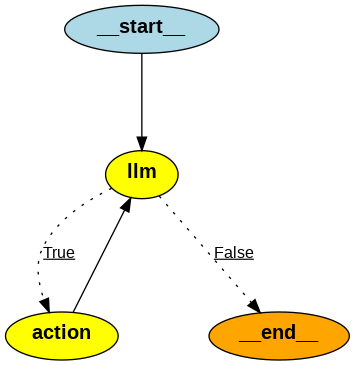

In [ ]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_png())

In [ ]:
## Code examples for the above agentic workflow
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

for i in result['messages']:
  pprint.pprint(i.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************ak0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [ ]:
pprint.pprint(result['messages'][-1].content)

NameError: name 'result' is not defined

In [ ]:
## Code examples for the above agentic workflow
messages = [HumanMessage(content="how's the performance of the S&P 500 in the last few weeks?")]
result = abot.graph.invoke({"messages": messages})

pprint.pprint(result['messages'][-1].content)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'S&P 500 performance in the last few weeks'}, 'id': 'call_Z9egRJebUCpCCn9jOYrXmRxo', 'type': 'tool_call'}
Back to the model!
('The S&P 500 has shown some fluctuations in the last few weeks. Here is a '
 'summary of the recent performance:\n'
 '\n'
 '- Aug 12, 2025: 6,445.76 (+1.13%)\n'
 '- Aug 11, 2025: 6,373.45 (-0.25%)\n'
 '- Aug 08, 2025: 6,389.45 (+0.78%)\n'
 '- Aug 07, 2025: 6,340.00 (-0.08%)\n'
 '- Aug 06, 2025: 6,345.06 (+0.73%)\n'
 '\n'
 'This data reflects the daily performance of the S&P 500 over the past week.')


## **Reasoning and Action Agents (ReAct)**

ReAct Graph is built on the intuition that by creating a feedback loop between the agent and the tools, we can answer complex questions with better accuracy. This graph consists of an agent node and a tools node. The tools node has all the functions that can be invoked by the agent.



### **ReAct Agent Execution Architecture**

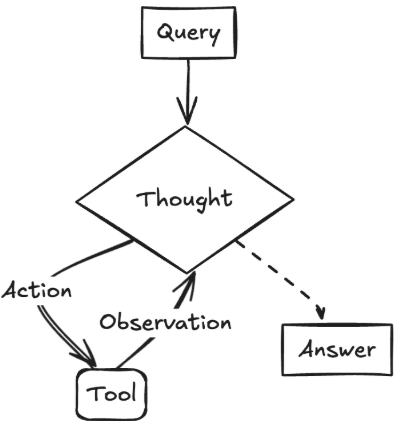

</br>


The architecture of a simple ReAct agent in LangGraph can be visualized as a cycle with two primary nodes: one for reasoning (calling the model) and one for acting (using tools).

The diagram above illustrates the agent's workflow:

1) The agent workflow receives a user query.</br>
2) The **Reasoning Agent Node** is activated, where the LLM thinks about the query and decides on the best action to take.</br>
3) The **Action Tool Node** is then triggered, which executes the chosen tool (e.g., a search engine or an API).</br>
4) The result of the action (the observation) is fed back into the agent's state.</br>
5) The agent then determines if the task is complete. If not, it returns to the reasoning node to continue the cycle until a final answer can be provided. For more complex tasks, additional nodes can be added to the graph, for instance, to ensure the agent produces structured output.</br>
</br>

LangGraph provides pre-built components, such as **create_react_agent**, that simplify the process of creating these agents, while still offering the flexibility to build them from scratch for more customized solutions.

### **Industry Use Cases**

The ability of ReAct agents to reason, use tools, and adapt makes them valuable across a wide range of industries as below:

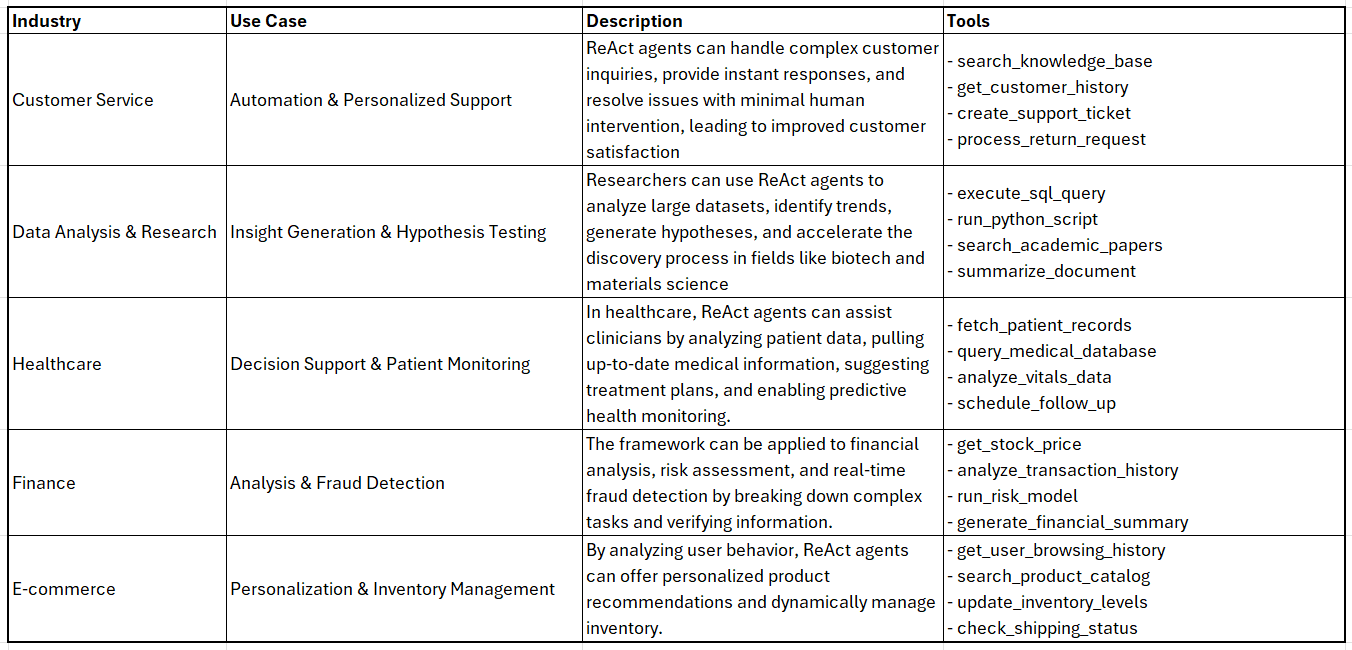

**Use Case 1 - Inventory Management Agent Workflow**

In the code below, we have defined an inventory management agent that can look up the current status, estimated delivery and availability of different products based on either their order number or product name. We will define two tools - **get_order_status** and **check_product_availability** that will aid the agent to fetch the right information for an input user query.

In [ ]:
# Define a mock database for orders and products for demonstration
mock_order_db = {
    "12345": {"status": "Shipped", "estimated_delivery": "2023-10-05"},
    "67890": {"status": "Processing", "estimated_delivery": "2023-10-08"},
}

mock_product_db = {
    "laptop01": {"name": "SuperFast Laptop", "availability": "In Stock"},
    "mouse02": {"name": "ErgoComfort Mouse", "availability": "Out of Stock"},
}

In [ ]:
# Define the tools for the agent
from langchain_core.tools import tool

@tool
def get_order_status(order_id: str) -> dict:
    """Gets the status of a given order ID."""
    return mock_order_db.get(order_id, {"status": "Order not found"})

@tool
def check_product_availability(product_id: str) -> dict:
    """Checks the availability of a given product ID."""
    return mock_product_db.get(product_id, {"availability": "Product not found"})

# Set up the tools to be used by the agent
tools = [
    get_order_status,
    check_product_availability,
]


# Define the AgentState
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], lambda x, y: x + y]

# Define the Agent class using LangGraph
class ReActAgent:
    def __init__(self, model, tools, checkpointer):
        self.model = model.bind_tools(tools)
        # The checkpointer saves the conversation state, allowing the agent to have persistent memory across multiple interactions.
        self.checkpointer = checkpointer
        self.graph = self._build_graph()

    def _build_graph(self):
        graph = StateGraph(AgentState)
        graph.add_node("call_model", self._call_model)
        graph.add_node("call_tool", self._call_tool)
        graph.add_conditional_edges(
            "call_model",
            lambda state: "call_tool" if state["messages"][-1].tool_calls else END,
        )
        graph.add_edge("call_tool", "call_model")
        graph.set_entry_point("call_model")
        return graph.compile(checkpointer=self.checkpointer)

    def _call_model(self, state: AgentState) -> dict:
        messages = state["messages"]
        response = self.model.invoke(messages)
        return {"messages": [response]}


    def _call_tool(self, state: AgentState) -> dict:
        last_message = state["messages"][-1]
        tool_call = last_message.tool_calls[0]
        tool = {
            "get_order_status": get_order_status,
            "check_product_availability": check_product_availability,
            "tavily_search_results_json": TavilySearchResults(max_results=1, tavily_api_key=TAVILY_API_KEY),
        }[tool_call["name"]]
        response = tool.invoke(tool_call["args"])
        return {"messages": [ToolMessage(content=str(response), tool_call_id=tool_call["id"])]}

# Initialize the agent
model = ChatOpenAI(model="gpt-3.5-turbo", api_key=userdata.get('OPENAI_API_KEY'), temperature=0)

# Function to run the agent with a sample query
async def run_agent(query):
    # Use AsyncSqliteSaver as an async context manager
    async with AsyncSqliteSaver.from_conn_string(":memory:") as checkpointer:
        # Initialize the agent INSIDE the "with" block
        react_agent = ReActAgent(model, tools, checkpointer)

        config = {"configurable": {"thread_id": "1"}}
        messages = [HumanMessage(content=query)]

        # Use the asynchronous .ainvoke() method
        result = await react_agent.graph.ainvoke({"messages": messages}, config)

        final_response = result["messages"][-1].content
        print(f"User Query: {query}")
        print(f"Agent Response: {final_response}")

In [ ]:
# Example Usage:
print("Example 1: Checking Order Status")
await run_agent("What is the status of my order, ID 67890?")

print("\n" + "="*30 + "\n")

print("Example 2: Checking Product Availability")
await run_agent("Is the ErgoComfort Mouse (mouse02) in stock?")

Example 1: Checking Order Status
User Query: What is the status of my order, ID 67890?
Agent Response: The status of your order with ID 67890 is "Processing" and the estimated delivery date is October 8, 2023.


Example 2: Checking Product Availability
User Query: Is the ErgoComfort Mouse (mouse02) in stock?
Agent Response: The ErgoComfort Mouse (mouse02) is currently out of stock.


### **Human-In-The-Loop**

Human-in-the-loop refers to the process of integrating human judgment and feedback into an agent's operational cycle . This is essential when an agent's decisions have real-world consequences, require nuanced understanding, or involve high-stakes actions . Instead of operating as a "black box," the agent can pause and request human input, approval, or correction before proceeding .

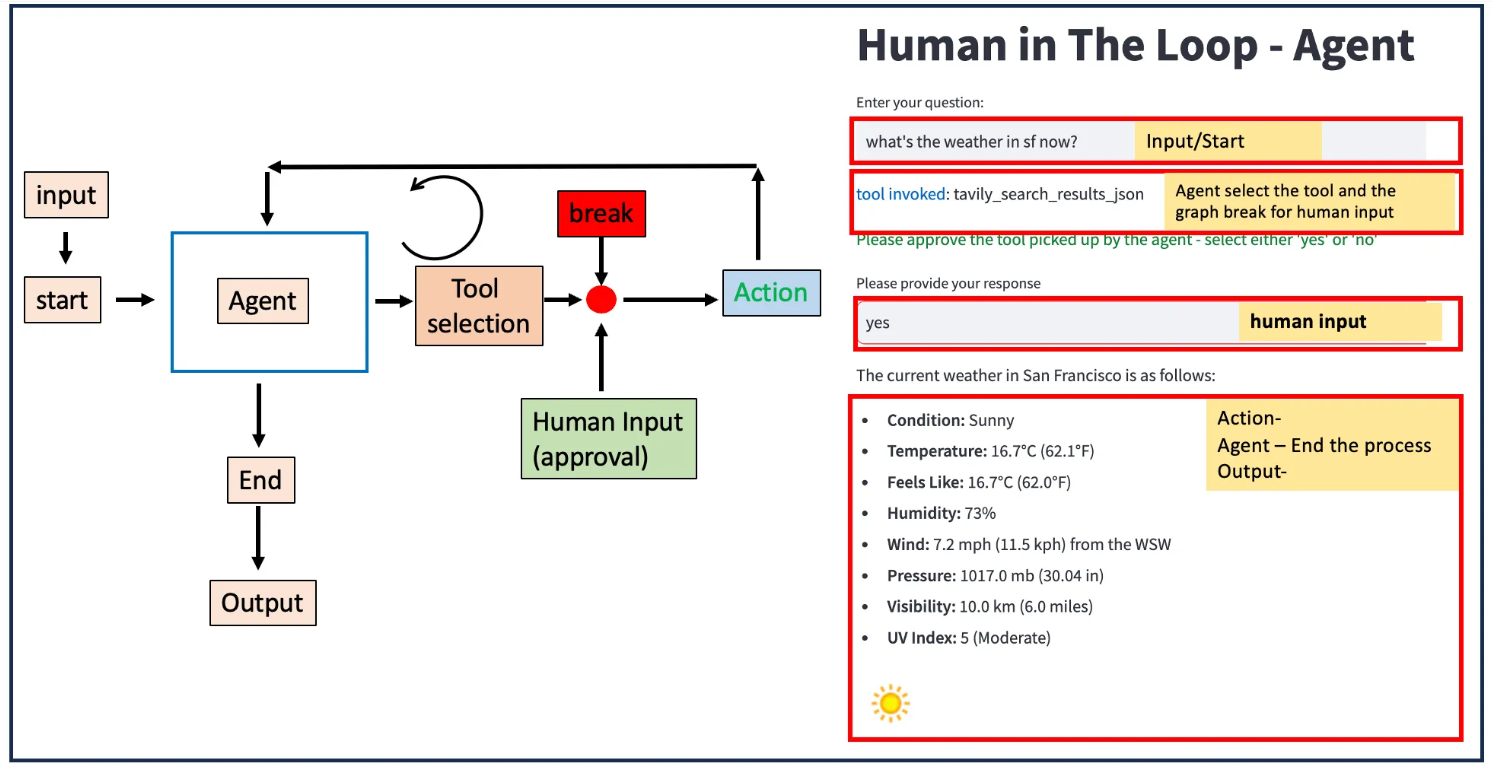

#### **Common HITL Patterns**

By leveraging interrupts and state management, developers can implement several common patterns for human-agent collaboration:

1) **Approve or Reject Actions**: The agent can pause before executing a critical step, such as making an API call, running a script, or sending a communication . A human can then review the proposed action and either approve it, allowing the agent to continue, or reject it, potentially guiding the agent toward an alternative path .

2) **Edit State**: A human can intervene to directly modify the agent's "memory" or state. This is useful for correcting mistakes, adding missing information, or refining the agent's understanding of the task at hand .

3) **Review and Edit Tool Calls**: Before an agent uses a tool (e.g., a search engine or a database query), it can present the planned tool call to a human. The user can then validate or even edit the parameters of the tool call to ensure it is accurate and safe .

4) **Validate or Clarify Input**: The agent can pause to ask clarifying questions or confirm its understanding of a user's request before proceeding with a complex or ambiguous task .

</br>
</br>

**LangGraph implementation**: The primary mechanism for enabling HITL in LangGraph is the interrupt function. This function can be used to pause the graph's execution to wait for human input . Interrupts can be implemented in two ways:

- Static Interrupts: These pause the graph at predefined points, such as before or after a specific node executes. This is useful for consistently requiring approval for certain types of actions .

- Dynamic Interrupts: These pause the graph from within a node based on the current state. For example, an agent might request human help only when it encounters a situation it is not confident about .

**Use Case 2 - Financial Research Analysis Agent Workflow**

In the below code, we have implemented an agent workflow that uses a HITL confirmation before executing two tools - get_stock_price and get_company_news.

In [ ]:
# Define a mock database for financial data for demonstration
from langchain_core.tools import tool

mock_stock_db = {
    "GOOGL": {"price": 150.00, "currency": "USD"},
    "MSFT": {"price": 300.00, "currency": "USD"},
}

mock_news_db = {
    "GOOGL": "Google announces new AI features for its search engine.",
    "MSFT": "Microsoft reports strong quarterly earnings, driven by cloud growth.",
}

# Define the tools for the agent
@tool
def get_stock_price(symbol: str) -> dict:
    """Gets the latest stock price for a given symbol."""
    return mock_stock_db.get(symbol, {"price": "Symbol not found"})

@tool
def get_company_news(symbol: str) -> str:
    """Gets the latest news for a given company symbol."""
    return mock_news_db.get(symbol, "News not found")

# Set up the tools to be used by the agent
tools = [
    get_stock_price,
    get_company_news,
]

# Define the AgentState
class AgentState(TypedDict):
    human_approval: str
    messages: Annotated[list[AnyMessage], lambda x, y: x + y]

# Define the Agent class with Human-in-the-Loop
class ReActAgentWithHumanApproval:
    def __init__(self, model, tools, checkpointer):
        self.model = model.bind_tools(tools)
        self.checkpointer = checkpointer
        self.graph = self._build_graph()

    def _build_graph(self):
        graph = StateGraph(AgentState)
        graph.add_node("call_model", self._call_model)
        graph.add_node("call_tool", self._call_tool)
        graph.add_node("human_in_the_loop", self._human_in_the_loop)

        graph.add_conditional_edges(
            "call_model",
            lambda state: "human_in_the_loop" if state["messages"][-1].tool_calls else END,
        )
        graph.add_conditional_edges(
        "human_in_the_loop",
        # Check the 'human_approval' field instead of message content
        lambda state: "call_tool" if state.get("human_approval") == "yes" else END,
        )
        graph.add_edge("call_tool", "call_model")
        graph.set_entry_point("call_model")
        return graph.compile(checkpointer=self.checkpointer)

    def _call_model(self, state: AgentState) -> dict:
        messages = state["messages"]
        response = self.model.invoke(messages)
        return {"messages": [response]}

    def _call_tool(self, state: AgentState) -> dict:
        last_message = state["messages"][-1]
        tool_call = last_message.tool_calls[0]
        tool = {
            "get_stock_price": get_stock_price,
            "get_company_news": get_company_news,
            "tavily_search_results_json": TavilySearchResults(max_results=1, tavily_api_key=TAVILY_API_KEY),
        }[tool_call["name"]]
        response = tool.invoke(tool_call["args"])
        return {"messages": [ToolMessage(content=str(response), tool_call_id=tool_call["id"])]}

    def _human_in_the_loop(self, state: AgentState) -> dict:
        last_message = state["messages"][-1]
        tool_call = last_message.tool_calls[0]
        print(f"\nAgent proposes to call the '{tool_call['name']}' tool with arguments: {tool_call['args']}")
        response = input("Do you approve? (yes/no): ")
        # Store the response in the new field, not in messages
        return {"human_approval": response}


# Initialize the agent
model = ChatOpenAI(model="gpt-3.5-turbo", api_key=userdata.get('OPENAI_API_KEY'), temperature=0)

# Function to run the agent with a sample query
async def run_agent_with_approval(query):
    # Use AsyncSqliteSaver as an async context manager
    async with AsyncSqliteSaver.from_conn_string(":memory:") as checkpointer:
        # Initialize the agent
        react_agent_with_approval = ReActAgentWithHumanApproval(model, tools, checkpointer)

        config = {"configurable": {"thread_id": "1"}}
        messages = [HumanMessage(content=query)]

        # Use the asynchronous .ainvoke() method
        result = await react_agent_with_approval.graph.ainvoke({"messages": messages}, config)

        final_response = result["messages"][-1].content
        print(f"User Query: {query}")
        print(f"Agent Response: {final_response}")


In [ ]:
# Example Usage:
print("Example 1: Getting Stock Price with Human Approval")
await  run_agent_with_approval("What is the current stock price of Google (GOOGL)?")

print("\n" + "="*30 + "\n")

print("Example 2: Getting Company News with Human Approval")

await  run_agent_with_approval("What's the latest news about Microsoft (MSFT)?")

Example 1: Getting Stock Price with Human Approval

Agent proposes to call the 'get_stock_price' tool with arguments: {'symbol': 'GOOGL'}
Do you approve? (yes/no): yes
User Query: What is the current stock price of Google (GOOGL)?
Agent Response: The current stock price of Google (GOOGL) is $150.00 USD.


Example 2: Getting Company News with Human Approval

Agent proposes to call the 'get_company_news' tool with arguments: {'symbol': 'MSFT'}
Do you approve? (yes/no): yes
User Query: What's the latest news about Microsoft (MSFT)?
Agent Response: The latest news about Microsoft (MSFT) is that they have reported strong quarterly earnings, driven by cloud growth.


## **Workshop Key Takeaways**

- **System Prompt & Tools**: System prompt provides instructions to an agent to teach it how to reason and use the tools (external functions) that each focus on completing a specific task.
- **AgentState** - AgentState is the internal, short-term memory of the agent (for a single session) that remembers the conversation history while interacting with a user and can be used to provide more context-aware responses
- **StateGraph** - StateGraph is a tool that defines the order of execution and flow of information between different steps of an agent workflow. It operates on a shared state of the entire workflow that is updated with every action taken.
- **ReAct Agents**: They solve complex problems by cyclically reasoning about what to do, taking action with a tool, and observing the result to inform the next step.
- **Human-in-the-Loop**: This capability allows for pausing an AI agent's process at critical moments to get human approval or input, ensuring safety and control before the agent proceeds.

## References

- https://python.langchain.com/docs/versions/migrating_memory/long_term_memory_agent/
- https://medium.com/@kbdhunga/implementing-human-in-the-loop-with-langgraph-ccfde023385c
- https://medium.com/@janani.seshadri/building-persistent-memory-in-agent-systems-with-langmem-0059c439e5ea
- https://learn.deeplearning.ai/courses/ai-agents-in-langgraph/lesson/qyrpc/introduction
- https://aima.cs.berkeley.edu/


## Exercise: Build a Simple E-commerce Assistant Agent

**Objective** </br>
Your goal is to build a basic AI agent for an online electronics store. The agent will act as a customer assistant that can check the price and inventory status of products. This exercise will test your understanding of creating Tools and writing clear System Prompt.
</br>
</br>
**Industry Problem** </br>
In any e-commerce business, customers constantly ask for product information like price and availability. Automating these simple queries with an AI agent can significantly improve customer service efficiency and free up human agents for more complex issues.
</br>
</br>
**Your Task** </br>
You will create an agent that uses two distinct tools to answer customer questions. You will need to define the tools and then write a system prompt that instructs the agent on how to use them.


In [ ]:
## Step 1: Implement the Tools (The "A" in PEAS)
# First, here is the product database. This dictionary represents the "Environment" your agent will interact with.
# Mock product database for our electronics store
product_db = {
    "laptop01": {"name": "SuperFast Laptop", "price": 1200, "availability": "In Stock"},
    "mouse02": {"name": "ErgoComfort Mouse", "price": 75, "availability": "In Stock"},
    "keyboard03": {"name": "Mechanical Pro Keyboard", "price": 150, "availability": "Out of Stock"},
}

In [ ]:
# Instructions: Complete the logic for the two tool functions below. They should look up the product_id in the product_db and return the correct information.

# TODO: Implement the logic for both tools

def get_product_price(product_id: str) -> str:
    """Gets the price of a given product ID."""
    # HINT: Check if product_id is a key in the product_db.
    # If it is, get the product's name and price and return a formatted string.
    # If not, return a 'product not found' message.
    pass # Remove this line and add your code

def check_product_availability(product_id: str) -> str:
    """Checks the availability of a given product ID."""
    # HINT: Check if product_id is a key in the product_db.
    # If it is, get the product's name and availability and return a formatted string.
    # If not, return a 'product not found' message.
    pass # Remove this line and add your code

# This dictionary maps the tool names to your functions.
known_actions = {
    "get_product_price": get_product_price,
    "check_product_availability": check_product_availability,
}

In [ ]:
## Step 2: Write the System Prompt (The "P" in PEAS)
# Instructions: Create a prompt variable containing your system prompt. It must clearly explain the "Thought, Action, PAUSE, Observation" loop and define the two available
# actions with examples, just as shown in the workshop notebook.

# TODO: Write your system prompt in this multi-line string.
prompt = """
# HINT: Explain the Thought, Action, PAUSE, Observation loop here.

# HINT: Define your available actions below, with examples.
# Action 1: get_product_price
# Action 2: check_product_availability
""".strip()

In [ ]:
## Step 3: Build the Agent Class
# Instructions: Complete the Agent class below. You will need to implement the logic for initializing the agent, handling a user message, and executing the call to the AI model based on
# the examples from the notebook.

# TODO: Complete the Agent class by filling in the methods.

class Agent:
    def __init__(self, system=""):
        # HINT: Initialize self.system and self.messages.
        # If a system prompt is provided, add it to the messages list.
        pass # Remove this line and add your code

    def __call__(self, message):
        # HINT: Append the user's message to self.messages.
        # Call the execute() method to get the model's result.
        # Append the model's result (assistant's message) to self.messages.
        # Return the result.
        pass # Remove this line and add your code

    def execute(self):
        # HINT: Call the OpenAI chat completions API with the model and messages.
        # Return the content of the first choice from the API response.
        # (Ensure your OpenAI API key is set up as a Colab secret)
        pass # Remove this line and add your code

In [ ]:
## Step 4: Test Your Agent!
# Once you have completed all the steps above, run the following cells to test your agent's ability to reason and use the tools you've built. You will need to manually run the tool
# function based on the agent's Action output and feed the result back in as an Observation.

# 1. Initialize your agent
ecommerce_agent = Agent(prompt)

# Test Query 1: Check Price
user_query_1 = "What is the price of the SuperFast Laptop (laptop01)?"
agent_action = ecommerce_agent(user_query_1)
print(agent_action)

# Test Query 2: Check Availability
user_query_2 = "Is the Mechanical Pro Keyboard (keyboard03) in stock?"
agent_action = ecommerce_agent(user_query_2)
print(agent_action)